# Wolf River: 8-year drought subsurface storage deficit

Compare `ensemble_1` **8_year_drought** to **baseline** using processed full runs and `read_simulation_data` from `paper_figures/utils.py`.

Sequence (`8_year_drought.json`): years 0–9 average, years 10–17 dry (8 years), year 18+ average recovery.

Snapshots:
- **End of drought**: simulation year 17 (last hour of the 8th dry year)
- **One year after drought**: simulation year 18 (end of first recovery year)

Deficit = 100 × (baseline − drought) / baseline (%), from column storage summed over `z`, masked to the domain.

Maps are **cutout heatmaps**: layer-wise percent deficit, averaged over **y** (z–x panel) or **x** (z–y panel).

In [7]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

sys.path.insert(0, str(Path("paper_figures").resolve()))
import utils

ENSEMBLE = "ensemble_1"
DOMAIN = "wolf"
DROUGHT_MEMBER = "8_year_drought"
BASELINE_MEMBER = "baseline"
DROUGHT_LENGTH_YEARS = 8
END_OF_DROUGHT_YEAR = utils.PERTURBATION_START_YEAR + DROUGHT_LENGTH_YEARS - 1
ONE_YEAR_AFTER_DROUGHT_YEAR = utils.PERTURBATION_START_YEAR + DROUGHT_LENGTH_YEARS
OUTLET_X = 18
OUTLET_Y = 21

In [8]:
drought = utils.read_simulation_data(ENSEMBLE, DROUGHT_MEMBER, DOMAIN)
baseline = utils.read_simulation_data(ENSEMBLE, BASELINE_MEMBER, DOMAIN)

print(f"Drought simulation years: {float(drought.time.min()):.2f} – {float(drought.time.max()):.2f}")
print(f"Baseline simulation years: {float(baseline.time.min()):.2f} – {float(baseline.time.max()):.2f}")
print(f"Target end-of-drought year: {END_OF_DROUGHT_YEAR}")
print(f"Target one-year-after year: {ONE_YEAR_AFTER_DROUGHT_YEAR}")

/glade/derecho/scratch/bwest/drought-ensemble/analysis/paper_figures/utils.py:35: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  data = xr.open_mfdataset(files, concat_dim="time", combine="nested")
/glade/derecho/scratch/bwest/drought-ensemble/analysis/paper_figures/utils.py:35: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars e

Drought simulation years: 0.00 – 16.00
Baseline simulation years: 0.00 – 11.00
Target end-of-drought year: 17
Target one-year-after year: 18


In [9]:
def column_storage(ds, year):
    """Total subsurface storage (m³) per (y, x) at simulation year `year`."""
    snap = ds.sel(time=year, method="nearest")
    return snap.storage.sum(dim="z"), float(snap.time)


def baseline_column_storage(baseline_ds, year):
    """Baseline storage at `year`, or last available year if baseline is shorter."""
    ref_year = min(float(year), float(baseline_ds.time.max()))
    snap = baseline_ds.sel(time=ref_year, method="nearest")
    return snap.storage.sum(dim="z"), float(snap.time)


def storage_pct_deficit_map(drought_ds, baseline_ds, year):
    """Column-integrated percent deficit (y, x) for domain summaries."""
    d_stor, d_t = column_storage(drought_ds, year)
    b_stor, b_t = baseline_column_storage(baseline_ds, year)
    mask2d = drought_ds.mask.isel(time=0).any(dim="z") > 0
    pct = (b_stor - d_stor) / b_stor * 100
    pct = pct.where(mask2d & (b_stor > 0))
    return pct, d_t, b_t


def layer_pct_deficit(drought_ds, baseline_ds, year):
    """Layer-wise percent deficit (z, y, x)."""
    d_snap = drought_ds.sel(time=year, method="nearest")
    ref_year = min(float(year), float(baseline_ds.time.max()))
    b_snap = baseline_ds.sel(time=ref_year, method="nearest")
    mask = d_snap.mask > 0
    pct = (b_snap.storage - d_snap.storage) / b_snap.storage * 100
    pct = pct.where(mask & (b_snap.storage > 0))
    return pct, float(d_snap.time), float(b_snap.time)


def x_cutout_heatmap(pct_layers):
    """z–x heatmap: mean percent deficit over y."""
    return pct_layers.mean(dim="y", skipna=True)


def y_cutout_heatmap(pct_layers):
    """z–y heatmap: mean percent deficit over x."""
    return pct_layers.mean(dim="x", skipna=True)


def plot_pct_deficit_cutouts(years, titles, suptitle):
    n = len(years)
    fig, axes = plt.subplots(2, n, figsize=(5.5 * n, 7), constrained_layout=True)
    if n == 1:
        axes = axes.reshape(2, 1)

    cutouts = []
    meta = []
    for year in years:
        pct, d_t, b_t = layer_pct_deficit(drought, baseline, year)
        cutouts.append((x_cutout_heatmap(pct), y_cutout_heatmap(pct)))
        meta.append((d_t, b_t))

    vmax_vals = []
    for x_map, y_map in cutouts:
        vmax_vals.append(float(x_map.max()))
        vmax_vals.append(float(y_map.max()))
    vmax = max(vmax_vals) if vmax_vals else None
    if vmax is not None and vmax <= 0:
        vmax = None

    im = None
    for j, (title, (x_map, y_map), (d_t, b_t)) in enumerate(zip(titles, cutouts, meta)):
        subtitle = f"{title}\ndrought t≈{d_t:.2f} yr, baseline t≈{b_t:.2f} yr"

        ax_x = axes[0, j]
        im = ax_x.imshow(
            x_map.values,
            origin="lower",
            aspect="auto",
            vmin=0,
            vmax=vmax,
            cmap="YlOrRd",
        )
        ax_x.axvline(OUTLET_X, color="k", ls=":", lw=1)
        ax_x.set_title(f"{subtitle}\nx cutout (mean over y)")
        ax_x.set_xlabel("x")
        ax_x.set_ylabel("z")

        ax_y = axes[1, j]
        im = ax_y.imshow(
            y_map.values,
            origin="lower",
            aspect="auto",
            vmin=0,
            vmax=vmax,
            cmap="YlOrRd",
        )
        ax_y.axvline(OUTLET_Y, color="k", ls=":", lw=1)
        ax_y.set_title("y cutout (mean over x)")
        ax_y.set_xlabel("y")
        ax_y.set_ylabel("z")

    if im is not None:
        fig.colorbar(im, ax=axes, label="Storage deficit (%)", shrink=0.85)
    fig.suptitle(suptitle)
    return fig

## Percent storage deficit cutouts

If processed outputs stop before years 17–18, xarray selects the nearest available drought timestep and the latest baseline year for comparison. Extend `file_locations.json` after more sequence years finish post-processing to reach the true end-of-drought and recovery snapshots.

In [10]:
pct_end, _, _ = storage_pct_deficit_map(drought, baseline, END_OF_DROUGHT_YEAR)
pct_after, _, _ = storage_pct_deficit_map(drought, baseline, ONE_YEAR_AFTER_DROUGHT_YEAR)

if float(drought.time.max()) < END_OF_DROUGHT_YEAR:
    print(
        f"WARNING: drought run ends at year {float(drought.time.max()):.2f}; "
        f"year {END_OF_DROUGHT_YEAR} snapshot uses nearest available time."
    )
if float(drought.time.max()) < ONE_YEAR_AFTER_DROUGHT_YEAR:
    print(
        f"WARNING: year {ONE_YEAR_AFTER_DROUGHT_YEAR} not in drought output yet; "
        f"recovery snapshot also uses nearest available time."
    )

mean_end = float(pct_end.mean(skipna=True))
mean_after = float(pct_after.mean(skipna=True))
print(
    f"Domain-mean percent deficit at end-of-drought (yr {END_OF_DROUGHT_YEAR}): "
    f"{mean_end:.2f}%"
)
print(
    f"Domain-mean percent deficit one year after (yr {ONE_YEAR_AFTER_DROUGHT_YEAR}): "
    f"{mean_after:.2f}%"
)

Domain-mean percent deficit at end-of-drought (yr 17): 0.03%
Domain-mean percent deficit one year after (yr 18): 0.03%


/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


NOTE: Both columns use the same drought timestep because processed output ends near year 16.0. Add years ≥18 to file_locations.json after post-processing to separate end-of-drought and recovery snapshots.


/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


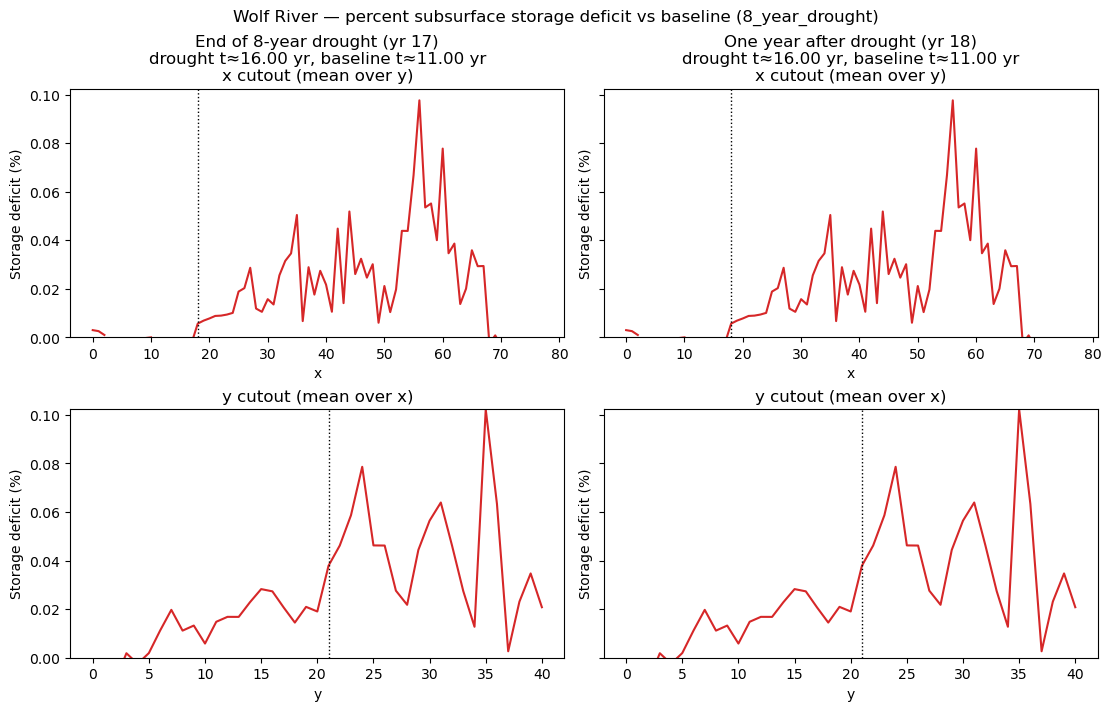

In [11]:
_, t_d_end, _ = storage_pct_deficit_map(drought, baseline, END_OF_DROUGHT_YEAR)
_, t_d_after, _ = storage_pct_deficit_map(drought, baseline, ONE_YEAR_AFTER_DROUGHT_YEAR)

if t_d_end == t_d_after:
    print(
        "NOTE: Both columns use the same drought timestep because processed output "
        f"ends near year {float(drought.time.max()):.1f}. "
        f"Add years ≥{ONE_YEAR_AFTER_DROUGHT_YEAR} to file_locations.json after post-processing "
        "to separate end-of-drought and recovery snapshots."
    )

fig = plot_pct_deficit_cutouts(
    [END_OF_DROUGHT_YEAR, ONE_YEAR_AFTER_DROUGHT_YEAR],
    [
        f"End of {DROUGHT_LENGTH_YEARS}-year drought (yr {END_OF_DROUGHT_YEAR})",
        f"One year after drought (yr {ONE_YEAR_AFTER_DROUGHT_YEAR})",
    ],
    f"Wolf River — percent subsurface storage deficit vs baseline ({DROUGHT_MEMBER})",
)
plt.show()

In [ ]:
# Domain-mean column storage through time (drought vs baseline at same simulation year)
mask2d = drought.mask.isel(time=0).any(dim="z") > 0
n_active = int(mask2d.sum())

drought_col = drought.storage.sum(dim="z").where(mask2d).mean(dim=["x", "y"])
baseline_col = baseline.storage.sum(dim="z").where(mask2d).mean(dim=["x", "y"])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(drought.time, drought_col, label="8-year drought", color="C3")
ax.plot(baseline.time, baseline_col, label="baseline", color="C0")
ax.axvline(END_OF_DROUGHT_YEAR, color="k", ls="--", lw=1, label="end of drought (yr 17)")
ax.axvline(ONE_YEAR_AFTER_DROUGHT_YEAR, color="gray", ls=":", lw=1, label="+1 yr (yr 18)")
ax.axvspan(utils.PERTURBATION_START_YEAR, END_OF_DROUGHT_YEAR + 1, alpha=0.1, color="C3")
ax.set_xlabel("Simulation year")
ax.set_ylabel("Mean column storage (m³)")
ax.set_title(f"Wolf — domain-mean column storage ({n_active} active cells)")
ax.legend(loc="best")
fig.tight_layout()
plt.show()